Dataset Shape: (2200, 8)

Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


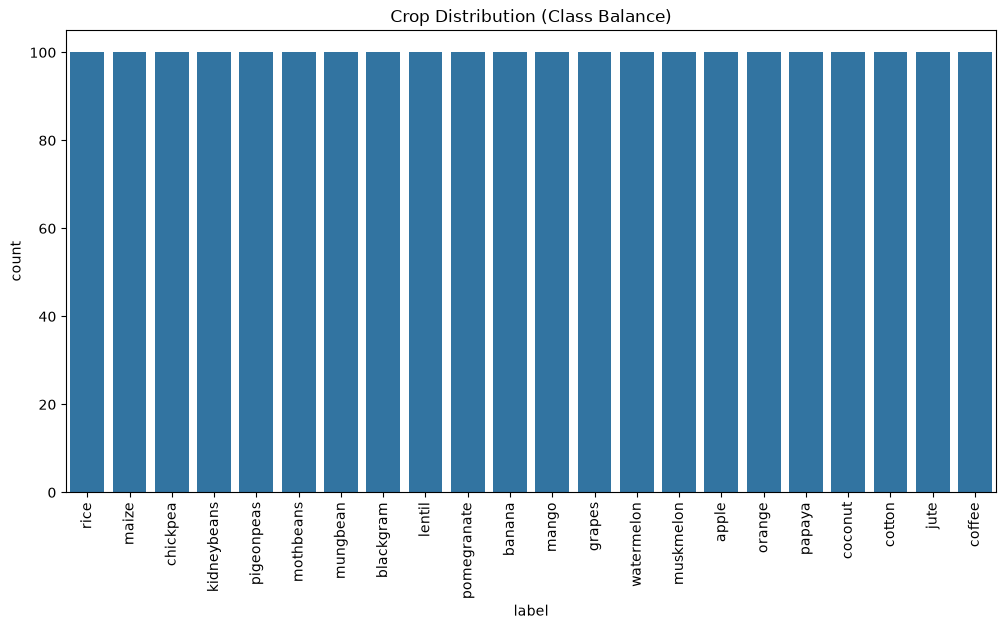

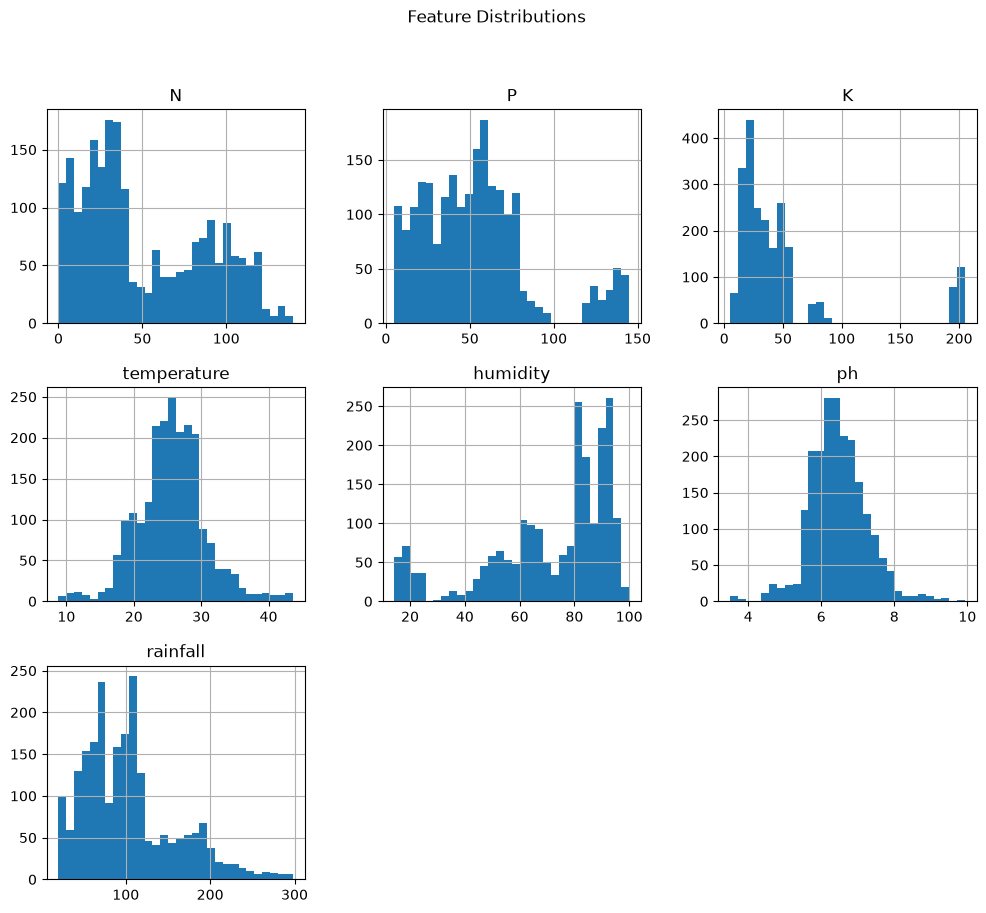

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset (update path if needed)
df = pd.read_csv('data/Crop_recommendation.csv')

# 2. Basic info and missing values
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# 3. Check Class Balance (Are there exactly 100 rows per crop?)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Crop Distribution (Class Balance)")
plt.show()

# 4. Check data distributions (Skewness)
df.drop('label', axis=1).hist(figsize=(12, 10), bins=30)
plt.suptitle("Feature Distributions")
plt.show()

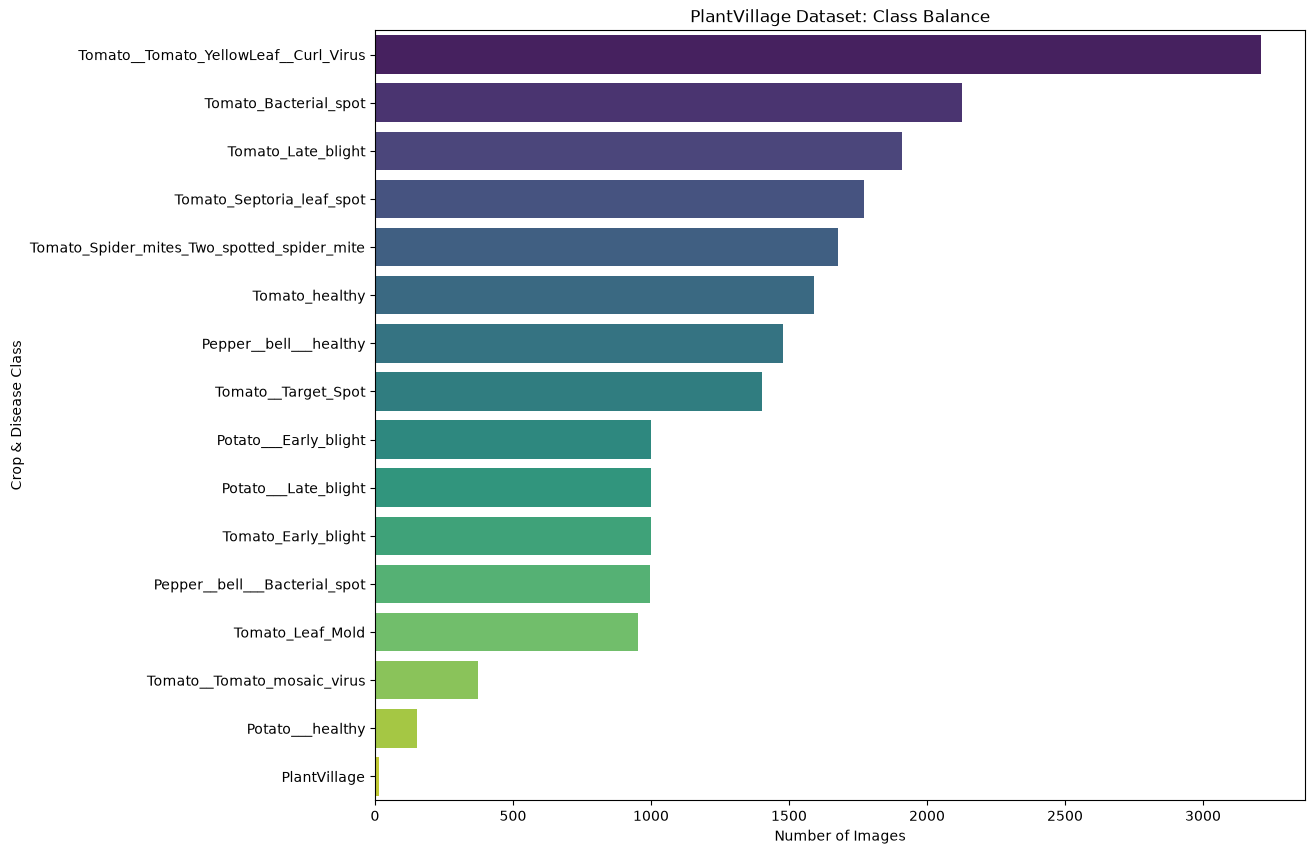

Total Disease/Crop Classes: 16
Total Images: 20655


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the path to the extracted PlantVillage folder
dataset_path = 'data/PlantVillage/'

# Loop through the folders and count the images
class_counts = {}
for folder_name in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder_name)
    if os.path.isdir(folder_path):
        num_images = len(os.listdir(folder_path))
        class_counts[folder_name] = num_images

# Convert our dictionary to a pandas DataFrame and sort it
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class Name', 'Image Count'])
df_counts = df_counts.sort_values(by='Image Count', ascending=False)

# Plot the distribution
plt.figure(figsize=(12, 10))
sns.barplot(data=df_counts, x='Image Count', y='Class Name', hue='Class Name', legend=False, palette='viridis')
plt.title("PlantVillage Dataset: Class Balance")
plt.xlabel("Number of Images")
plt.ylabel("Crop & Disease Class")
plt.show()

# Print the summary stats
print(f"Total Disease/Crop Classes: {len(class_counts)}")
print(f"Total Images: {df_counts['Image Count'].sum()}")